In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [5]:
df.shape

(920, 16)

In [6]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['num'] = df['num'].apply(lambda x:0 if x==0 else 1)

In [13]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns

In [22]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Tajeswini\AppData\Local\Temp\ipykernel_3488\4074283006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [23]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Tajeswini\AppData\Local\Temp\ipykernel_3488\1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Tajeswini\AppData\Local\Temp\ipykernel_3488\1925696021.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0]

In [24]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

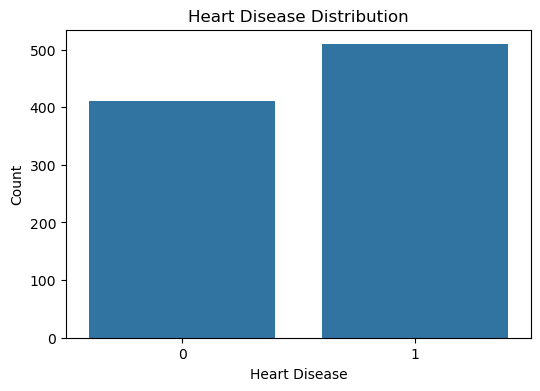

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

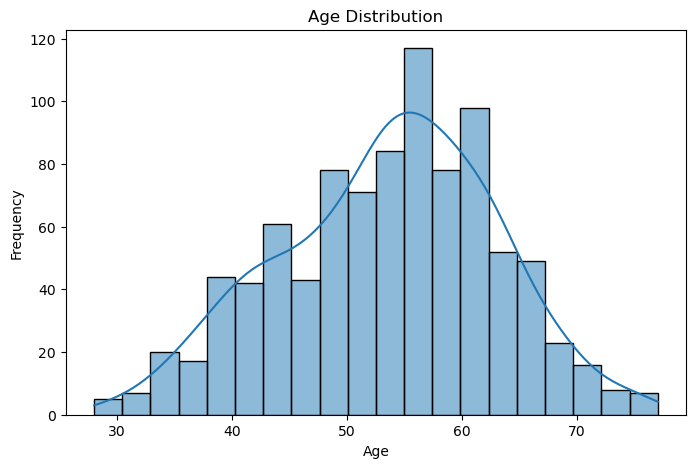

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

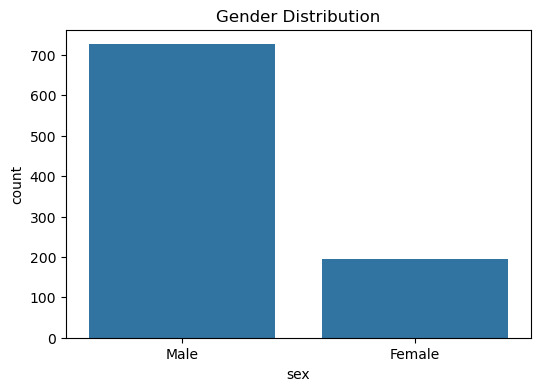

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")

plt.show()

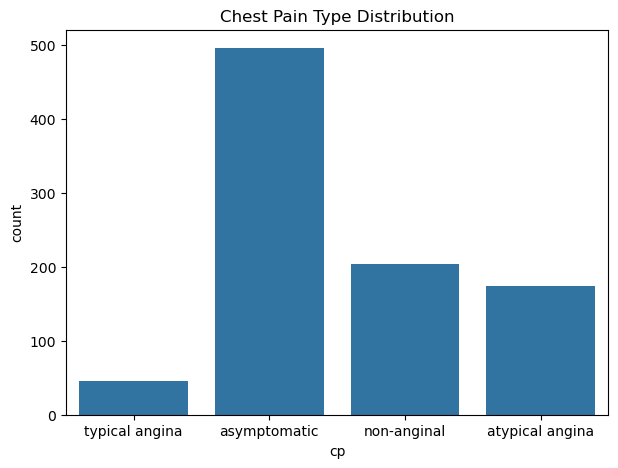

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(x='cp', data=df)

plt.title("Chest Pain Type Distribution")

plt.show()

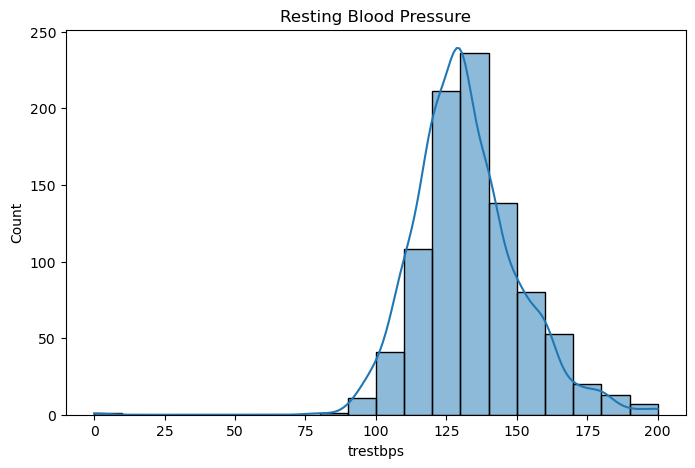

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['trestbps'], bins=20, kde=True)

plt.title("Resting Blood Pressure")

plt.show()

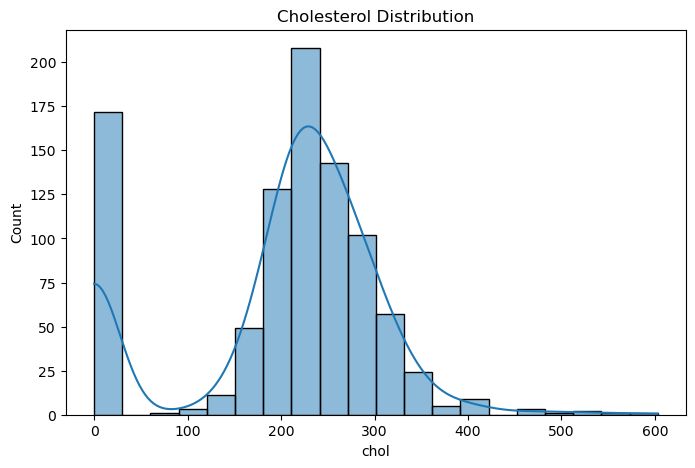

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=20, kde=True)

plt.title("Cholesterol Distribution")

plt.show()

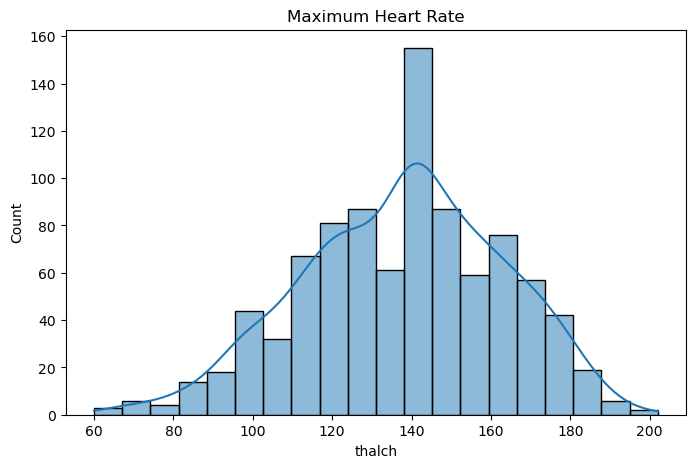

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['thalch'], bins=20, kde=True)

plt.title("Maximum Heart Rate")

plt.show()

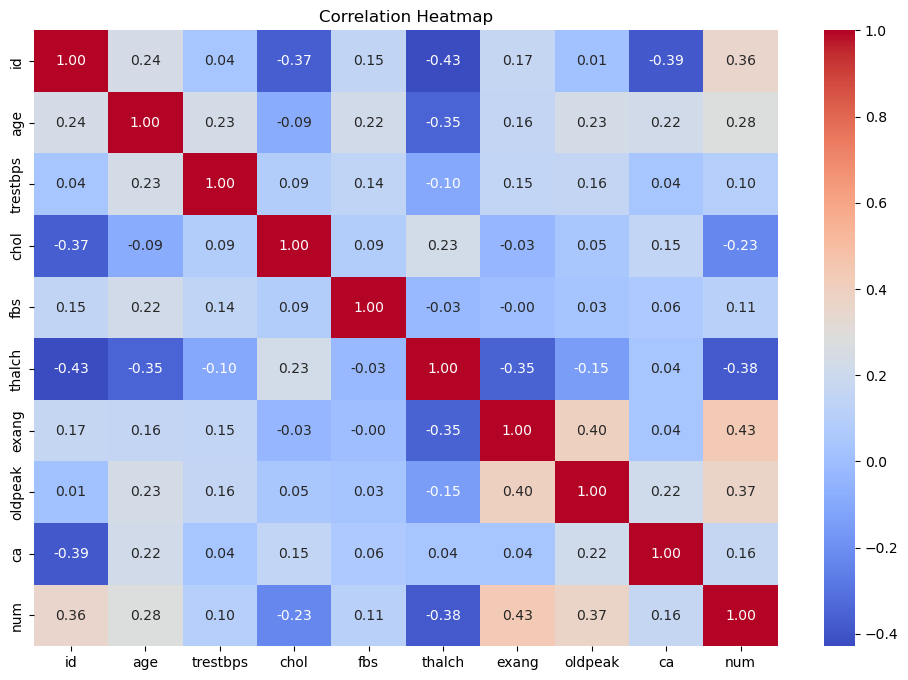

In [32]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

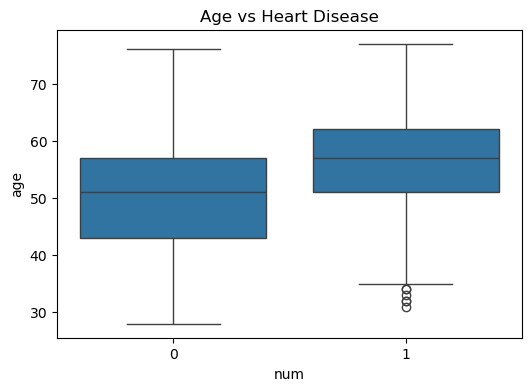

In [33]:
plt.figure(figsize=(6,4))

sns.boxplot(x='num',
            y='age',
            data=df)

plt.title("Age vs Heart Disease")

plt.show()

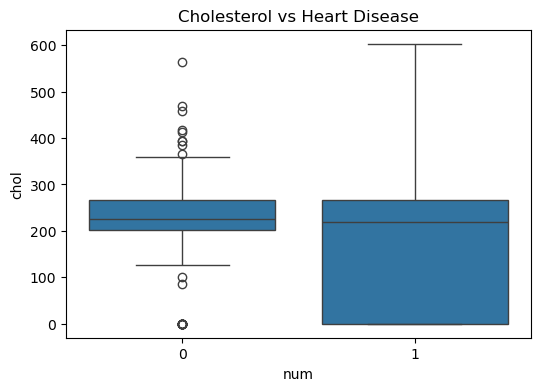

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(x='num',
            y='chol',
            data=df)

plt.title("Cholesterol vs Heart Disease")

plt.show()

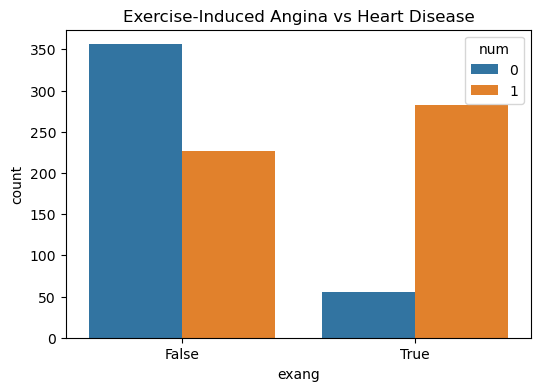

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(x='exang',
              hue='num',
              data=df)

plt.title("Exercise-Induced Angina vs Heart Disease")

plt.show()

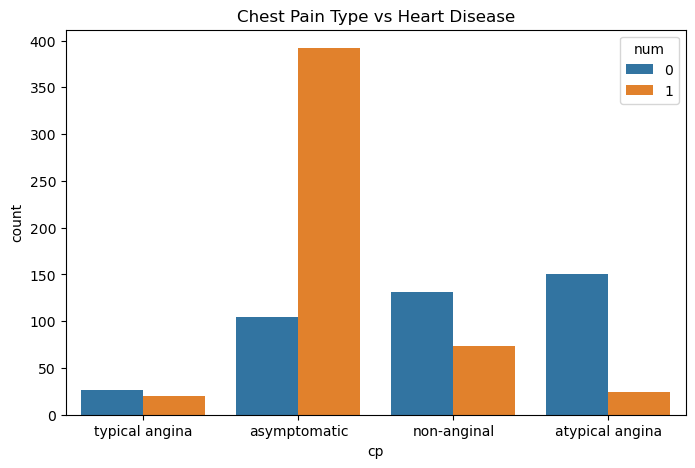

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(x='cp',
              hue='num',
              data=df)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

In [37]:
df.drop(['id', 'dataset'], axis=1, inplace=True)

In [38]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [39]:
X = df.drop('num', axis=1)

y = df['num']

In [40]:
X.dtypes

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
ca          float64
thal         object
dtype: object

In [41]:
cat_cols = X.select_dtypes(include='object').columns

cat_cols

Index(['sex', 'cp', 'restecg', 'slope', 'thal'], dtype='object')

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

In [43]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,3,145.0,233.0,True,0,150.0,False,2.3,0,0.0,0
1,67,1,0,160.0,286.0,False,0,108.0,True,1.5,1,3.0,1
2,67,1,0,120.0,229.0,False,0,129.0,True,2.6,1,2.0,2
3,37,1,2,130.0,250.0,False,1,187.0,False,3.5,0,0.0,1
4,41,0,1,130.0,204.0,False,0,172.0,False,1.4,2,0.0,1


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [45]:
X = pd.DataFrame(X_scaled, columns=X.columns)

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,1.007386,0.516931,2.319860,0.705176,0.303643,2.380476,-1.567991,0.489727,-0.760292,1.368109,-2.234081,-0.361400,-2.397813
1,1.432034,0.516931,-0.818774,1.518569,0.789967,-0.420084,-1.567991,-1.181478,1.315283,0.611589,-0.295067,4.411152,-0.328406
2,1.432034,0.516931,-0.818774,-0.650479,0.266939,-0.420084,-1.567991,-0.345875,1.315283,1.651804,-0.295067,2.820301,1.741001
3,-1.752828,0.516931,1.273649,-0.108217,0.459634,-0.420084,0.015491,1.961979,-0.760292,2.502889,-2.234081,-0.361400,-0.328406
4,-1.328180,-1.934494,0.227437,-0.108217,0.037541,-0.420084,-1.567991,1.365120,-0.760292,0.517024,1.643946,-0.361400,-0.328406


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(736, 13)
(184, 13)
(736,)
(184,)


In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
lr = LogisticRegression(random_state=42)

In [50]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [51]:
y_pred_lr = lr.predict(X_test)

In [52]:
print("Predicted Values:")
print(y_pred_lr[:10])

print("Actual Values:")
print(y_test.values[:10])

Predicted Values:
[0 0 1 1 0 0 0 1 1 0]
Actual Values:
[0 0 1 1 1 0 1 1 1 0]


In [53]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [54]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

precision_lr = precision_score(y_test, y_pred_lr)

print("Precision:", precision_lr)

recall_lr = recall_score(y_test, y_pred_lr)

print("Recall:", recall_lr)

f1_lr = f1_score(y_test, y_pred_lr)

print("F1 Score:", f1_lr)

Accuracy: 0.782608695652174
Precision: 0.8631578947368421
Recall: 0.7522935779816514
F1 Score: 0.803921568627451


In [55]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[62 13]
 [27 82]]


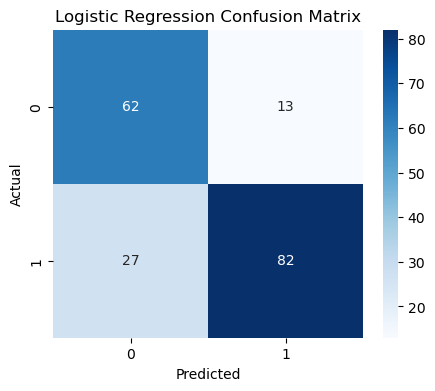

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      0.83      0.76        75
           1       0.86      0.75      0.80       109

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.80      0.78      0.78       184



In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
accuracy = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    accuracy.append(accuracy_score(y_test, pred))

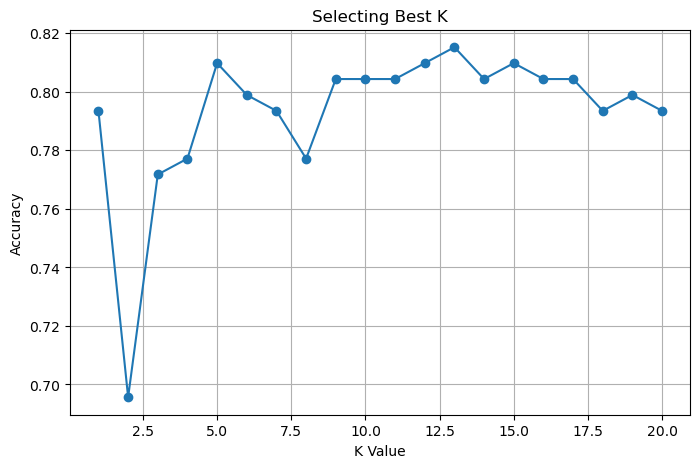

In [60]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Selecting Best K")

plt.grid()

plt.show()

In [61]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [62]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1 :", f1_score(y_test, y_pred_knn))

Accuracy : 0.7934782608695652
Precision: 0.865979381443299
Recall : 0.7706422018348624
F1 : 0.8155339805825242


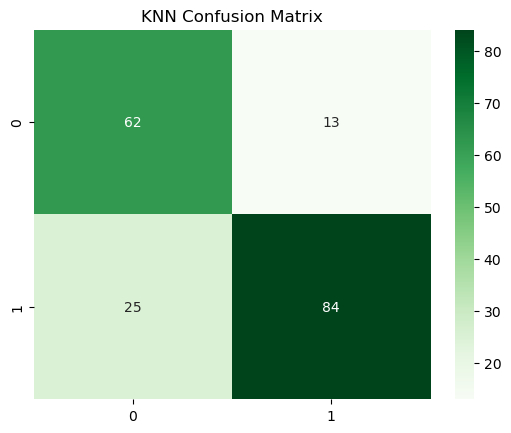

In [63]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("KNN Confusion Matrix")

plt.show()

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
y_pred_dt = dt.predict(X_test)

In [67]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 :", f1_score(y_test, y_pred_dt))

Accuracy : 0.8043478260869565
Precision: 0.8476190476190476
Recall : 0.8165137614678899
F1 : 0.8317757009345794


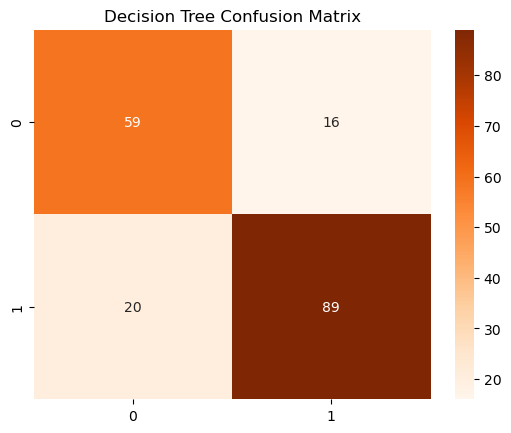

In [68]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [69]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.782609,0.863158,0.752294,0.803922
1,KNN,0.793478,0.865979,0.770642,0.815534
2,Decision Tree,0.804348,0.847619,0.816514,0.831776


In [70]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [71]:
lr_prob = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

auc_lr = roc_auc_score(y_test, lr_prob)

print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.8606727828746178


In [72]:
knn_prob = knn.predict_proba(X_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)

auc_knn = roc_auc_score(y_test, knn_prob)

print("KNN AUC:", auc_knn)

KNN AUC: 0.868868501529052


In [73]:
dt_prob = dt.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

auc_dt = roc_auc_score(y_test, dt_prob)

print("Decision Tree AUC:", auc_dt)

Decision Tree AUC: 0.8015902140672782


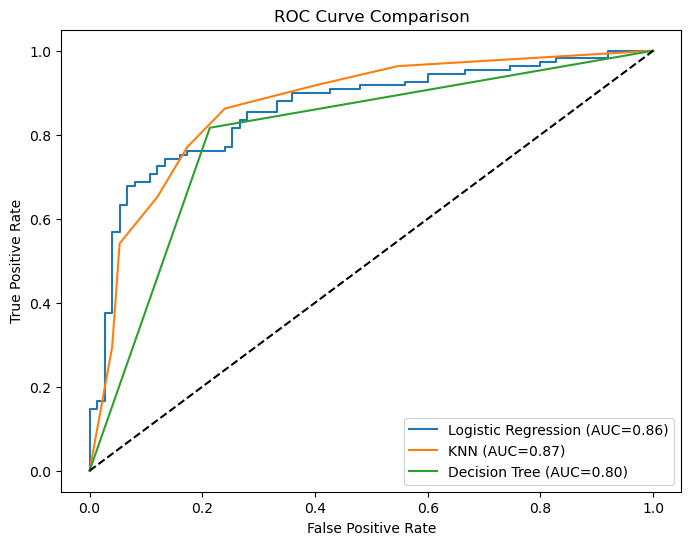

In [74]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={auc_lr:.2f})')

plt.plot(fpr_knn, tpr_knn,
         label=f'KNN (AUC={auc_knn:.2f})')

plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC={auc_dt:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [75]:
import pickle

In [76]:
pickle.dump(lr, open("heart_model.pkl", "wb"))

In [77]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [78]:
model = pickle.load(open("heart_model.pkl", "rb"))

In [79]:
prediction = model.predict(X_test)

print(prediction[:10])

[0 0 1 1 0 0 0 1 1 0]


In [80]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ],
    "AUC": [
        auc_lr,
        auc_knn,
        auc_dt
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.782609,0.863158,0.752294,0.803922,0.860673
1,KNN,0.793478,0.865979,0.770642,0.815534,0.868869
2,Decision Tree,0.804348,0.847619,0.816514,0.831776,0.801590


In [81]:
import os
print(os.getcwd())

C:\Users\Tajeswini\internship 26


In [82]:
import os

print("Current Folder:", os.getcwd())
print("\nFiles:")
print(os.listdir())

Current Folder: C:\Users\Tajeswini\internship 26

Files:
['.ipynb_checkpoints', 'a1.txt', 'app.py', 'Assignment-Copy1.ipynb', 'Assignment2.ipynb', 'assignment3.ipynb', 'Assignment4-Copy1.ipynb', 'Assignment_1.ipynb', 'Assignment_2.ipynb', 'Assignment_3.ipynb', 'Assignment_4.ipynb', 'banknotes.csv', 'Boston.csv', 'cleaned_products.csv', 'grapes_new.csv', 'heart.csv', 'heart_disease_uci.csv', 'heart_model.pkl', 'ingredients.csv', 'July13_KNN.ipynb', 'July14_Random_Forest.ipynb', 'July15.ipynb', 'July15_Feature_selection.ipynb', 'July16_MLPRoject.ipynb', 'July1_Logistic_Regression.ipynb', 'July2_Clustering.ipynb', 'July6n8_Polynomial_Regression.ipynb', 'July8_Decision_Tree.ipynb', 'july9_Decision_Tree.ipynb', 'June10_File.ipynb', 'June11_file_handling.ipynb', 'June15_NumPy.ipynb', 'June15_Pandas.ipynb', 'June16.ipynb', 'June17_Exception_handling.ipynb', 'June17_Pandas.ipynb', 'June18.ipynb', 'June1_Data_Structure.ipynb', 'June22_Data_Cleaning.ipynb', 'June22_Data_Visualization.ipynb', 'Ju

In [83]:
import os

os.startfile(os.getcwd())